In [1]:
import pandas as pd 
import time
from functools import wraps
import matplotlib.pyplot as plt
import math
import networkx as nx

In [70]:
def create_dense_graph(size):
    arestas = []
    for i in range(size):
        for j in range(size):
            if (i != j):
                arestas.append([i,j])
    return arestas

In [18]:
def medir_tempo(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        inicio = time.time()
        resultado = func(*args, **kwargs)
        fim = time.time()
        return resultado,round(fim - inicio,6)
    return wrapper


# @medir_tempo
def condicional_prob(graph,node_1,node_2):


    mapa = graph.groupby(0)[1].apply(set).to_dict()

    p_cima,p_baixo = [len(mapa.get(node_2,[]))/len(mapa)],[]

    vizinhança_node_1 = list(mapa.get(node_1,[]))
    p_baixo.append(len(mapa.get(vizinhança_node_1[1],[]))/len(mapa))

    i = 0

    condicionante_cima = mapa.get(node_2,set())
    condionate_baixo = mapa.get(vizinhança_node_1[1],set())


    while True:
        (mapa.get(vizinhança_node_1[i],set())).intersection(condicionante_cima)
        p_cima.append(len(list((mapa.get(vizinhança_node_1[i],set()).intersection(condicionante_cima))))/ len(list(condicionante_cima)))
        condicionante_cima = mapa.get(vizinhança_node_1[i],set()).intersection(condicionante_cima)
        i += 1 
        # print(len(condicionante_cima))
        if len(list(condicionante_cima)) <= 1:
            break
    i = 2

    # vizinhança_node_1 = list(mapa.get(node_1,[]))

    while True:
        (mapa.get(vizinhança_node_1[i],set())).intersection(condionate_baixo)
        p_baixo.append(len(list((mapa.get(vizinhança_node_1[i],set()).intersection(condionate_baixo))))/ len(list(condionate_baixo)))
        condionate_baixo = mapa.get(vizinhança_node_1[i],set()).intersection(condionate_baixo)
        i += 1 
        # print(len(condionate_baixo))
        if len(list(condionate_baixo))  <= 1 :
            break

        aux = 1
        for i in p_cima:
            aux = aux*i

        for j in p_baixo:
            aux = aux/j
        return aux


In [35]:
grafo_original = pd.read_csv("/home/edu/Area_de_Trabalho/Projs/links/data/movies/testes/grafo_0.csv",header=None).head(100)
grafo_invertido = grafo_original.rename(columns={0: 1, 1: 0})[[0,1]]

# Concatena os dois
grafo = pd.concat([grafo_original, grafo_invertido], ignore_index=True)

mini = grafo.copy()

In [36]:
mini["valor"] = grafo.apply(lambda x:condicional_prob(grafo,x[0],x[1]),axis=1)

IndexError: list index out of range

In [33]:
mini

,0,1,valor
0,107,1,None
1,107,356,None
2,107,502,None
3,107,551,None
4,107,589,None
...,...,...,...
195,5515,150,NaN
196,7609,150,NaN
197,8332,150,NaN
198,10419,150,NaN


In [72]:
tempos = []
for i in range(10,100):
    print(i)
    df = pd.DataFrame(create_dense_graph(i),columns= None)
    tempos.append(condicional_prob(df,0,1))

10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [74]:
tempos[0]

([[[0.9,
    1.0,
    0.8888888888888888,
    0.875,
    0.8571428571428571,
    0.8333333333333334,
    0.8,
    0.75,
    0.6666666666666666,
    0.5]],
  [[0.9, 0.8888888888888888]]],
 0.002407)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (90, 2) + inhomogeneous part.

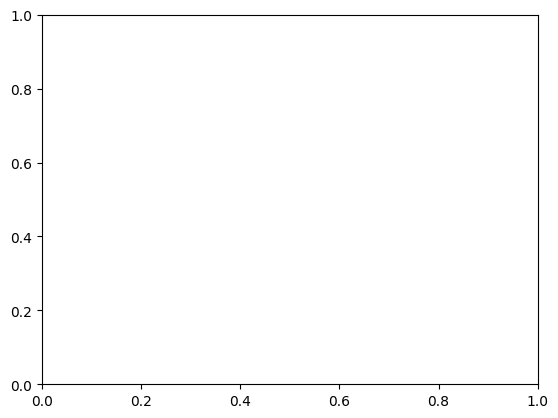

In [75]:
plt.scatter([i for i in range(len(tempos))],tempos,label = "dados experimentais")
# plt.scatter([i for i in range(1,1000)],[i*math.log(i,2)/30000 for i in range(1,1000)])
# plt.scatter([i for i in range(1,1000)],[math.sqrt(i)*math.log(i,2)/1000 for i in range(1,1000)])
# plt.plot([i for i in range(1,1000)],[(i**2)/3500000 for i in range(1,1000)],label= "a*x**2",c= "black")

plt.legend()
plt.ylabel("Tempo de calculo")
plt.xlabel("N")
plt.show()

In [59]:
tempos = [[] for i in range(10)]
for i in range(5,15):
    print(i)
    G = nx.erdos_renyi_graph(2**i,0.2)
    df = pd.DataFrame(G.edges(),columns= None)
    tempos[i-5].append(condicional_prob(df,0,1))


5
6
7
8
9
10
11
12
13
14


In [68]:
G.edges()

KeyboardInterrupt: 

In [ ]:
tempos[1].append(condicional_prob(df,0,1)[1])


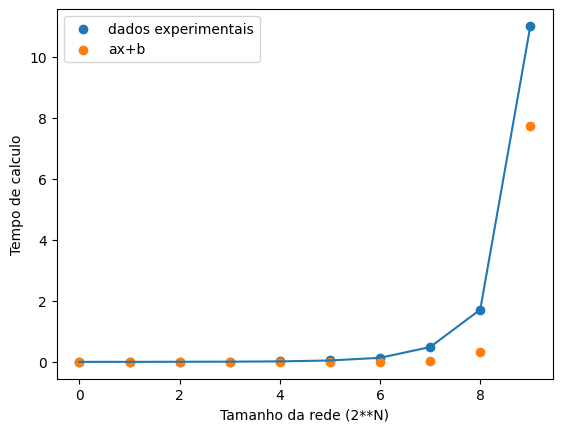

In [41]:
# plt.scatter(graus,tempos,label = "dados experimentais")
# plt.show()
# tempos = pd.DataFrame(tempos)
# plt.scatter([i for i in range(100,1000)],[sum(tempos[i].values[0:9])/len(tempos[i].values[0:9]) for i in range(100,1000)],label = "dados experimentais")
# plt.scatter([i for i in range(100,1000)],[i/200000+0.018 for i in range(100,1000)],label = "ax+b")

plt.scatter([i for i in range(0,10)],[tempos[1][i] for i in range(0,10)],label = "dados experimentais")
plt.plot([i for i in range(0,10)],[tempos[1][i] for i in range(0,10)])

plt.scatter([i for i in range(0,10)],[(i**i)/50000000 for i in range(0,10)],label = "ax+b")



plt.legend()
plt.ylabel("Tempo de calculo")
plt.xlabel("Tamanho da rede (2**N)")
plt.show()

In [126]:
sum(tempos[0].values[0:9])/len(tempos[0].values[0:9])

np.float64(0.0035973333333333335)

In [179]:
len(tempos[1])

1900